In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/data.csv")

print(df.shape)
print(df.iloc[:, 0])        # participant IDs
print(df.iloc[:, -1].value_counts())  # P vs H counts

(174, 452)
0        id_1
1        id_2
2        id_3
3        id_4
4        id_5
        ...  
169    id_170
170    id_171
171    id_172
172    id_173
173    id_174
Name: ID, Length: 174, dtype: str
class
P    89
H    85
Name: count, dtype: int64


In [3]:
X = df.drop(columns=['ID', 'class'])   # 450 features
y = (df['class'] == 'P').astype(int)   # 1 = Patient, 0 = Healthy

print(X.shape)          # should be (174, 450)
print(y.value_counts())

(174, 450)
class
1    89
0    85
Name: count, dtype: int64


In [4]:
print(X.isnull().sum().sum())   # hopefully 0

0


In [5]:
# See the 18 feature names (just look at task 1)
task1_cols = [c for c in X.columns if c.endswith('1')]
print(task1_cols)

['air_time1', 'disp_index1', 'gmrt_in_air1', 'gmrt_on_paper1', 'max_x_extension1', 'max_y_extension1', 'mean_acc_in_air1', 'mean_acc_on_paper1', 'mean_gmrt1', 'mean_jerk_in_air1', 'mean_jerk_on_paper1', 'mean_speed_in_air1', 'mean_speed_on_paper1', 'num_of_pendown1', 'paper_time1', 'pressure_mean1', 'pressure_var1', 'total_time1', 'air_time11', 'disp_index11', 'gmrt_in_air11', 'gmrt_on_paper11', 'max_x_extension11', 'max_y_extension11', 'mean_acc_in_air11', 'mean_acc_on_paper11', 'mean_gmrt11', 'mean_jerk_in_air11', 'mean_jerk_on_paper11', 'mean_speed_in_air11', 'mean_speed_on_paper11', 'num_of_pendown11', 'paper_time11', 'pressure_mean11', 'pressure_var11', 'total_time11', 'air_time21', 'disp_index21', 'gmrt_in_air21', 'gmrt_on_paper21', 'max_x_extension21', 'max_y_extension21', 'mean_acc_in_air21', 'mean_acc_on_paper21', 'mean_gmrt21', 'mean_jerk_in_air21', 'mean_jerk_on_paper21', 'mean_speed_in_air21', 'mean_speed_on_paper21', 'num_of_pendown21', 'paper_time21', 'pressure_mean21', '

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (139, 450), Test: (35, 450)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

print(classification_report(y_pred, y_test, target_names=['Healthy', 'Patient']))

              precision    recall  f1-score   support

     Healthy       0.59      0.77      0.67        13
     Patient       0.83      0.68      0.75        22

    accuracy                           0.71        35
   macro avg       0.71      0.73      0.71        35
weighted avg       0.74      0.71      0.72        35



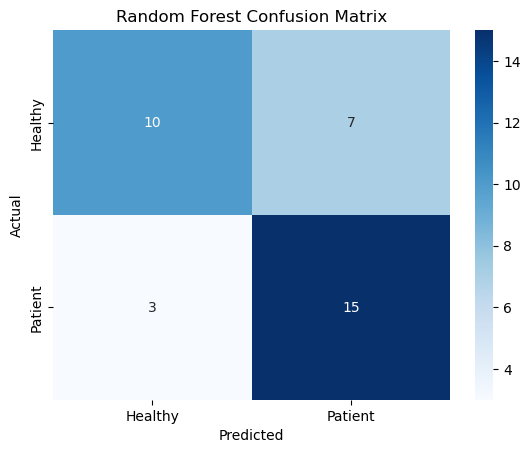

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Patient'],
            yticklabels=['Healthy', 'Patient'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [9]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Per fold: {scores.round(3)}")

CV Accuracy: 0.774 ± 0.129
Per fold: [0.8   0.914 0.829 0.8   0.529]


In [10]:
from sklearn.feature_selection import SelectKBest, f_classif

# Try keeping only top 50 features instead of all 450
selector = SelectKBest(f_classif, k=50)
X_selected = selector.fit_transform(X, y)

scores_reduced = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_selected, y, cv=5, scoring='accuracy'
)
print(f"Reduced CV Accuracy: {scores_reduced.mean():.3f} ± {scores_reduced.std():.3f}")

Reduced CV Accuracy: 0.821 ± 0.129


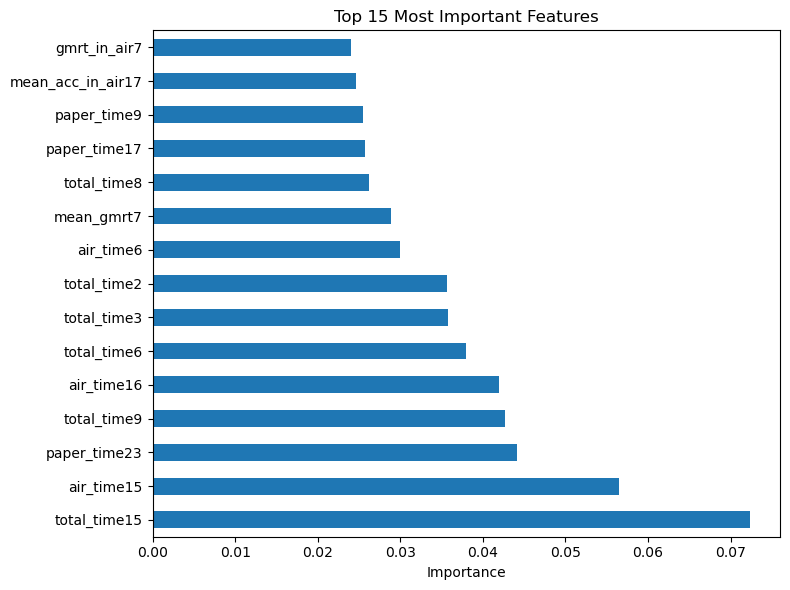

In [11]:
# Get selected feature names
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]

# Plot feature importances from random forest
rf_reduced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_reduced.fit(X_selected, y)

importances = pd.Series(rf_reduced.feature_importances_, index=selected_features)
importances.nlargest(15).plot(kind='barh', figsize=(8, 6))
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [12]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)
scores_svm = cross_val_score(svm, X_selected, y, cv=5, scoring='accuracy')
print(f"SVM CV Accuracy: {scores_svm.mean():.3f} ± {scores_svm.std():.3f}")
print(f"Per fold: {scores_svm.round(3)}")

SVM CV Accuracy: 0.868 ± 0.067
Per fold: [0.886 0.971 0.771 0.886 0.824]


In [13]:
for k in [20, 30, 50, 75, 100]:
    sel = SelectKBest(f_classif, k=k)
    X_k = sel.fit_transform(X, y)
    score = cross_val_score(SVC(kernel='rbf', random_state=42), 
                            X_k, y, cv=5).mean()
    print(f"k={k}: {score:.3f}")

k=20: 0.839
k=30: 0.862
k=50: 0.868
k=75: 0.862
k=100: 0.862
